# Longitudinal Modulus from Compression: Final Equilibrated State

## Theory

$$M = \frac{\sigma'_{zz}}{\varepsilon_{zz}}$$

Network stress from poroelasticity decomposition:
$$p_p(z) = -\frac{\sigma_{s,zz}(z)}{\phi_s(z)}, \qquad \sigma'_{zz}(z) = \sigma_{p,zz}(z) + \phi_p(z)\,p_p(z)$$

Cooperative diffusivity from relaxation:
$$\frac{\partial \phi_p}{\partial t} = D_c \frac{\partial^2 \phi_p}{\partial z^2}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
import os
from pathlib import Path
import matplotlib.font_manager as fm

plt.rcParams.update({
    'font.family': 'CMU Serif',
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'CMU Serif',
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 25,
    'xtick.labelsize': 23,
    'ytick.labelsize': 23,
    'legend.fontsize': 23,
    'figure.titlesize': 22,
})

print('Imports successful')


Imports successful


## Configuration

In [2]:
sim_name = 'walled_slab_support_5beads_tall_rho04_1.0_1.0_500000_1.0_1.0_2000000'
stress_data_dir = '../../flow_data_local/partial_stress_data/'
traj_file = f'../../flow_data_local/traj_files/gel_flow_{sim_name}.lammpstrj'
output_folder = '../../flow_data_local/flow_plots/'
binWidth = 2.0
phi_gel_threshold = 0.1
ci_level = 0.95

## Helper Functions

In [3]:
def read_ave_time_file(filepath):
    data_by_time = []
    with open(filepath, 'r') as f:
        lines = [l for l in f if not l.startswith('#') and l.strip()]
    i = 0
    while i < len(lines):
        parts = lines[i].split()
        if len(parts) == 2:
            timestep, nrows = int(parts[0]), int(parts[1])
            values = []
            for j in range(1, nrows + 1):
                if i + j < len(lines):
                    vp = lines[i + j].split()
                    if len(vp) == 2:
                        values.append(float(vp[1]))
            if values:
                data_by_time.append((timestep, np.arange(1, len(values)+1), np.array(values)))
            i += nrows + 1
        else:
            i += 1
    return data_by_time


def read_strain_file(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            rows.append([float(v) for v in line.split()])
    if not rows:
        raise ValueError(f'No data in {filepath}')
    if len(rows) == 2 and all(len(r)==1 for r in rows):
        return None, np.array([rows[0][0]]), np.array([rows[1][0]])
    if len(rows) == 1 and len(rows[0]) == 2:
        return None, np.array([rows[0][0]]), np.array([rows[0][1]])
    if all(len(r)==3 for r in rows):
        arr = np.array(rows)
        ts, col1, col2 = arr[:,0].astype(int).tolist(), arr[:,1], arr[:,2]
        ratio = np.nanmedian(col2) / np.nanmedian(col1)
        dL = col2 if ratio < 0.5 else col1 - col2
        return ts, col1, dL
    raise ValueError(f'Unrecognised format in {filepath}')


def read_lammpstrj_frame(filepath, frame_idx=0):
    with open(filepath) as f:
        lines = f.readlines()
    starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
    if frame_idx < 0: frame_idx = len(starts) + frame_idx
    s = starts[frame_idx]
    e = starts[frame_idx+1] if frame_idx+1<len(starts) else len(lines)
    fl = lines[s:e]
    timestep = int(fl[1].strip())
    box = {'x': [float(v) for v in fl[5].split()],
           'y': [float(v) for v in fl[6].split()],
           'z': [float(v) for v in fl[7].split()]}
    atoms = [[int(p[0]),int(p[1]),int(p[2]),float(p[3]),float(p[4]),float(p[5])]
             for p in [l.split() for l in fl[9:9+int(fl[3].strip())]]]
    return timestep, box, atoms


def compute_volume_fractions_1d(atoms_data, box_bounds, bin_width, direction='z'):
    a = np.array(atoms_data)
    typ, pos = a[:,1].astype(int), a[:,3:6]
    pm, sm = (typ==1)|(typ==2), (typ==3)
    d = {'x':0,'y':1,'z':2}[direction]
    lo, hi = box_bounds[direction]
    edges = np.arange(lo, hi+bin_width, bin_width)
    centers = (edges[:-1]+edges[1:])/2
    phi_p, phi_s = np.zeros(len(centers)), np.zeros(len(centers))
    for i,(a_,b_) in enumerate(zip(edges[:-1],edges[1:])):
        mask = (pos[:,d]>=a_)&(pos[:,d]<b_)
        np_, ns_, nt = np.sum(pm&mask), np.sum(sm&mask), np.sum(mask)
        if nt>0: phi_p[i], phi_s[i] = np_/nt, ns_/nt
    return centers, phi_p, phi_s

def compute_volume_fractions_1d_voronoi(atoms_data, box_bounds, bin_width, direction='z'):
    import tess
    import time

    a = np.array(atoms_data)
    typ = a[:,1].astype(int)
    pos = a[:,3:6]

    xlo, xhi = box_bounds['x']
    ylo, yhi = box_bounds['y']
    zlo, zhi = box_bounds['z']
    L = np.array([xhi-xlo, yhi-ylo, zhi-zlo])
    origin = np.array([xlo, ylo, zlo])

    # Filter to mobile atoms only (polymer + solvent) — exclude walls/support/piston
    mobile_mask = (typ == 1) | (typ == 2) | (typ == 3)
    typ_m = typ[mobile_mask]
    pos_m = pos[mobile_mask]

    # Wrap into box
    pos_wrapped = origin + (pos_m - origin) % L

    # Check for duplicates — voro++ will fail on coincident points
    print(f'  Checking for duplicate positions...')
    _, unique_idx = np.unique(np.round(pos_wrapped, 6), axis=0, return_index=True)
    n_dupes = len(pos_wrapped) - len(unique_idx)
    if n_dupes > 0:
        print(f'  Warning: removing {n_dupes} duplicate positions')
        pos_wrapped = pos_wrapped[unique_idx]
        typ_m = typ_m[unique_idx]

    print(f'  Building Voronoi container ({len(pos_wrapped)} atoms)...')
    t0 = time.time()
    cntr = tess.Container(
        pos_wrapped,
        limits=((xlo, ylo, zlo), (xhi, yhi, zhi)),
        periodic=True
    )
    print(f'  Container built ({time.time()-t0:.1f}s)')

    print(f'  Extracting cell volumes...')
    t0 = time.time()
    voronoi_volumes = np.array([c.volume() for c in cntr])
    print(f'  Volumes extracted ({time.time()-t0:.1f}s)')

    # Sanity check
    box_vol = L[0] * L[1] * L[2]
    voro_total = np.sum(voronoi_volumes)
    if abs(voro_total - box_vol) / box_vol > 0.01:
        print(f'  Warning: Voronoi volume {voro_total:.2f} differs from box {box_vol:.2f} by '
              f'{100*abs(voro_total-box_vol)/box_vol:.1f}%')

    # Bin along direction
    d = {'x': 0, 'y': 1, 'z': 2}[direction]
    lo, hi = box_bounds[direction]
    edges   = np.arange(lo, hi + bin_width, bin_width)
    centers = (edges[:-1] + edges[1:]) / 2

    pm = (typ_m == 1) | (typ_m == 2)
    sm = (typ_m == 3)

    phi_p = np.zeros(len(centers))
    phi_s = np.zeros(len(centers))

    for i, (a_, b_) in enumerate(zip(edges[:-1], edges[1:])):
        mask    = (pos_wrapped[:, d] >= a_) & (pos_wrapped[:, d] < b_)
        V_p     = np.sum(voronoi_volumes[mask & pm])
        V_s     = np.sum(voronoi_volumes[mask & sm])
        V_total = np.sum(voronoi_volumes[mask])
        if V_total > 0:
            phi_p[i] = V_p / V_total
            phi_s[i] = V_s / V_total

    return centers, phi_p, phi_s


def mean_ci(values, ci_level=0.95):
    v = values[~np.isnan(values)]
    n = len(v)
    if n==0: return np.nan, np.nan, np.nan
    if n==1: return v[0], v[0], v[0]
    m = np.mean(v)
    lo, hi = stats.t.interval(ci_level, df=n-1, loc=m, scale=stats.sem(v))
    return m, lo, hi


print('Helper functions defined')

Helper functions defined


## Step 1: Extract All Data

Read trajectory frames, compute count-based $\phi_p(z)$, and partial stresses for every snapshot.
This is the only slow step.

In [4]:
# ── Read stress data ──
stress_data = {}
for key, fp in [
    ('polymer_z', f'{stress_data_dir}stress_z_polymer_{sim_name}.dat'),
    ('solvent_z', f'{stress_data_dir}stress_z_solvent_{sim_name}.dat'),
]:
    print(f'Reading {key} ...')
    stress_data[key] = read_ave_time_file(fp)

n_stress = len(stress_data['polymer_z'])
print(f'Stress snapshots: {n_stress}')

# ── Read strain ──
strain_file = f'{stress_data_dir}strain_zz_{sim_name}.dat'
ts_strain, L_arr, dL_arr = read_strain_file(strain_file)
L_final  = L_arr[-1]  if len(L_arr)>1 else L_arr[0]
dL_final = dL_arr[-1] if len(dL_arr)>1 else dL_arr[0]
eps_final = dL_final / L_final
print(f'Final: L={L_final:.4f}, ΔL={dL_final:.4f}, ε={eps_final:.4f}')

# ── Match stress snapshots to trajectory frames ──
traj_timestep_to_frame = {}
with open(traj_file) as f:
    lines = f.readlines()
starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
for frame_idx, s in enumerate(starts):
    traj_timestep_to_frame[int(lines[s+1].strip())] = frame_idx

print(f'Trajectory frames: {len(starts)}')

matched = []
for idx in range(n_stress):
    stress_ts = stress_data['polymer_z'][idx][0]
    if stress_ts in traj_timestep_to_frame:
        matched.append((idx, traj_timestep_to_frame[stress_ts]))
    else:
        nearest = min(traj_timestep_to_frame.keys(), key=lambda t: abs(t - stress_ts))
        print(f'  Warning: stress ts={stress_ts} not in traj, using nearest ts={nearest}')
        matched.append((idx, traj_timestep_to_frame[nearest]))

n_snapshots = len(matched)
print(f'Matched {n_snapshots} snapshots')

# ── Loop once: extract everything ──
all_timesteps      = []
all_phi_p          = []  # count-based
all_phi_s          = []  # count-based
all_sigma_p_zz     = []
all_sigma_s_zz     = []
z_cnt = None  # count-based z grid (normalised), set on first iteration

for count, (stress_idx, frame_idx) in enumerate(matched):
    if (count+1) % max(1, n_snapshots//9) == 0 or count == 0:
        print(f'  {count+1}/{n_snapshots}')

    _, box, atoms = read_lammpstrj_frame(traj_file, frame_idx)

    # Count-based volume fractions
    z_i, phi_p_i, phi_s_i = compute_volume_fractions_1d(atoms, box, binWidth, 'z')
    all_phi_p.append(phi_p_i)
    all_phi_s.append(phi_s_i)

    if z_cnt is None:
        zlo, zhi = box['z']
        Lz = zhi - zlo
        z_cnt = (z_i - zlo) / Lz

    # Stress profiles
    ts = stress_data['polymer_z'][stress_idx][0]
    bins_z = stress_data['polymer_z'][stress_idx][1]
    z_coords = bins_z * binWidth - binWidth/2
    sig_p = stress_data['polymer_z'][stress_idx][2]
    sig_s = stress_data['solvent_z'][stress_idx][2]

    all_timesteps.append(ts)
    all_sigma_p_zz.append(sig_p)
    all_sigma_s_zz.append(sig_s)

z_norm = (z_coords - zlo) / Lz
all_phi_p = np.array(all_phi_p)
all_phi_s = np.array(all_phi_s)

print(f'\nDone. t = {all_timesteps[0]} → {all_timesteps[-1]}')
print(f'φ_p shape: {all_phi_p.shape}')

# Aliases for backward compatibility with later cells
z_centers = z_i
z_centers_norm = z_cnt


Reading polymer_z ...
Reading solvent_z ...
Stress snapshots: 9
Final: L=116.2075, ΔL=13.4826, ε=0.1160
Trajectory frames: 200
Matched 9 snapshots
  1/9
  2/9
  3/9
  4/9
  5/9
  6/9
  7/9
  8/9
  9/9

Done. t = 400000 → 2000000
φ_p shape: (9, 75)


## Step 2: Partial Stress Evolution

Saved: ../../flow_data_local/flow_plots/equilibration_check_walled_slab_support_5beads_tall_rho04_1.0_1.0_500000_1.0_1.0_2000000.png


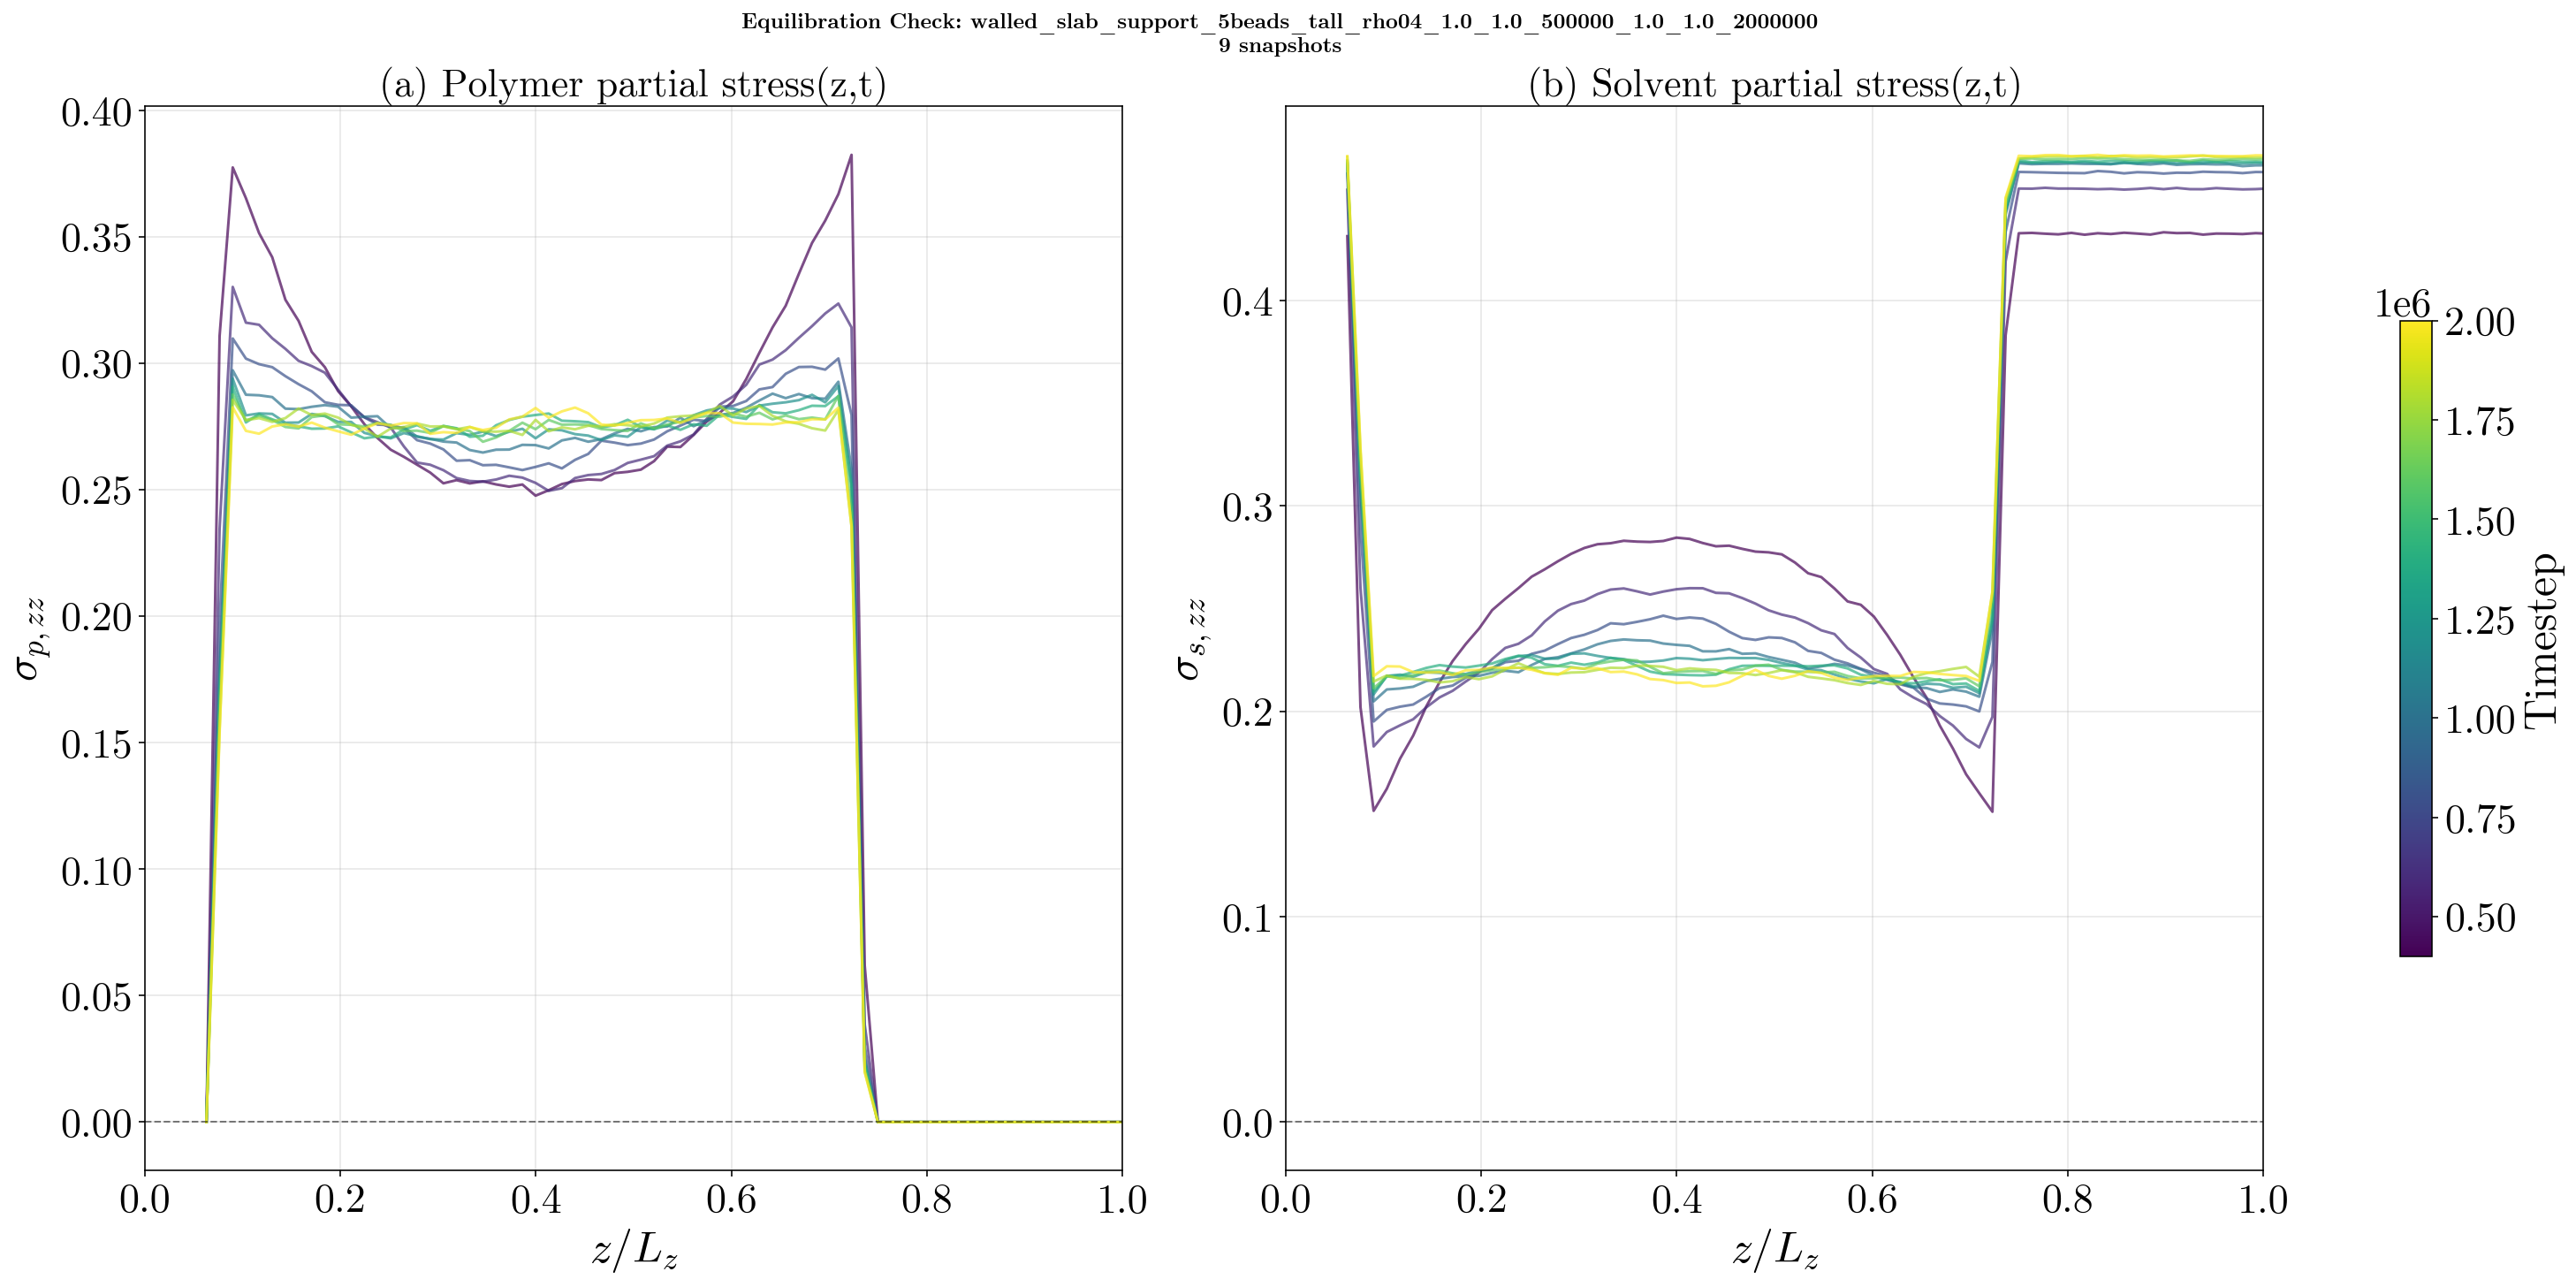

In [5]:
colors = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
alpha = 0.7

fig = plt.figure(figsize=(20, 10), constrained_layout=True)
fig.suptitle(
    f'Equilibration Check: {sim_name}\n{n_snapshots} snapshots',
    fontsize=12, fontweight='bold')

gs = gridspec.GridSpec(1, 2, figure=fig)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

for i in range(n_snapshots):
    ax_a.plot(z_norm, all_sigma_p_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_a.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_a.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{p,zz}$', title=r'(a) Polymer partial stress(z,t)', xlim=(0,1))
ax_a.grid(alpha=0.3)

for i in range(n_snapshots):
    ax_b.plot(z_norm, all_sigma_s_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_b.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_b.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{s,zz}$', title=r'(b) Solvent partial stress(z,t)', xlim=(0,1))
ax_b.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1]))
sm.set_array([])
cb = fig.colorbar(sm, ax=[ax_a, ax_b], fraction=0.015, pad=0.04)
cb.set_label('Timestep')

out1 = Path(output_folder) / f'equilibration_check_{sim_name}.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved: {out1}')
plt.show()


## Step 3: Polymer Volume Fraction Evolution

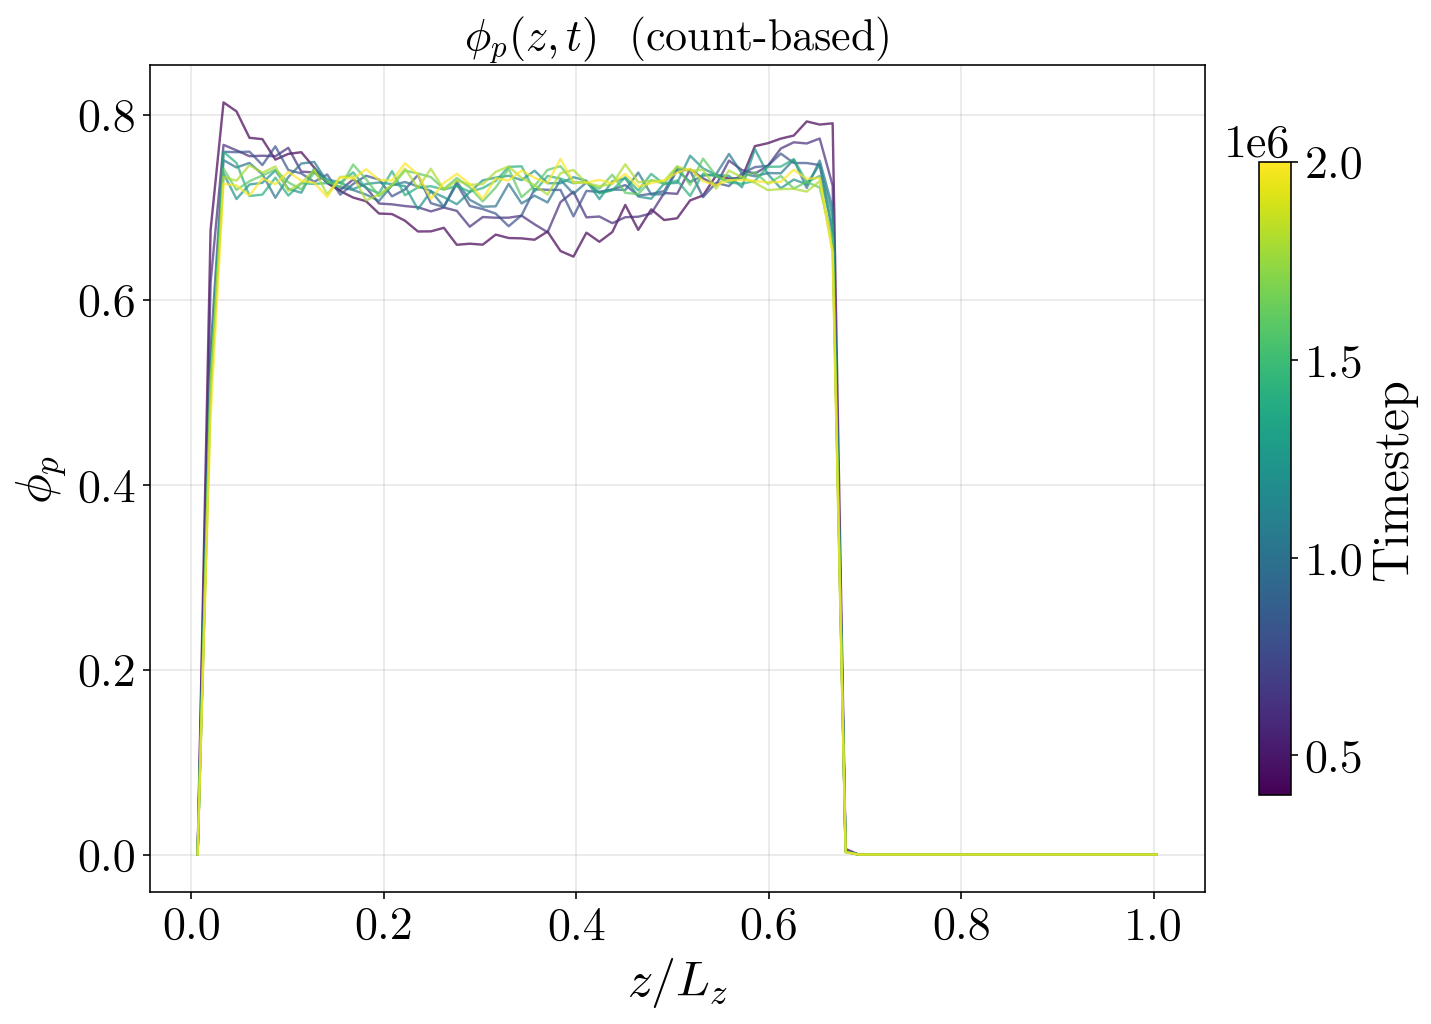

In [6]:
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
norm = Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1])
cmap = plt.cm.viridis

for i in range(n_snapshots):
    ax.plot(z_cnt, all_phi_p[i], '-', color=cmap(norm(all_timesteps[i])), lw=1.2, alpha=0.7)

ax.set(xlabel='$z / L_z$', ylabel=r'$\phi_p$', title=r'$\phi_p(z, t)$  (count-based)')
ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Timestep')

plt.savefig(Path(output_folder) / f'phi_p_evolution_{sim_name}.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Cooperative Diffusivity $D_c$

Decompose the initial $\phi_p(z, t_0)$ into cosine modes (no-flux BCs) on the gel domain:
$$\phi_p(z,t) = \frac{a_0}{2} + \sum_{n=1}^{N} a_n \cos\!\left(\frac{n\pi(z - z_L)}{L_\mathrm{gel}}\right) e^{-D_c (n\pi/L_\mathrm{gel})^2 (t - t_0)}$$

Fit a single scalar $D_c$ by minimising the squared residual across all snapshots.

In [25]:
binWidth_Dc = binWidth  # redefine here if desired

# ── Identify gel domain ──
edge_margin = 0
gel_bins = np.where(all_phi_p[0] > phi_gel_threshold)[0]
i_left  = gel_bins[0]  + edge_margin
i_right = gel_bins[-1] - edge_margin + 1

z_gel   = z_cnt[i_left:i_right]
z_L, z_R = z_gel[0], z_gel[-1]
L_gel   = z_R - z_L
phi_gel = all_phi_p[:, i_left:i_right]

times  = np.array(all_timesteps, dtype=float)
t0     = times[0]
dt_arr = times - t0

print(f'Gel domain: z/Lz ∈ [{z_L:.3f}, {z_R:.3f}], L_gel/Lz = {L_gel:.3f}, {len(z_gel)} bins')

# ── Cosine decomposition of initial profile ──
N_modes = 2
zeta    = (z_gel - z_L) / L_gel
phi_init = phi_gel[0]
a0 = 2.0 * np.mean(phi_init)
a_n = np.zeros(N_modes)
for n in range(1, N_modes + 1):
    a_n[n-1] = 2.0 * np.trapz(phi_init * np.cos(n * np.pi * zeta), zeta)

print(f'Cosine modes: {N_modes}, a0/2 = {a0/2:.4f}')
print(f'|a_1| = {abs(a_n[0]):.4e}, |a_2| = {abs(a_n[1]):.4e}')

# ── Analytical solution ──
def phi_model(Dc, z_norm, dt):
    result = np.full_like(z_norm, a0 / 2.0)
    for n in range(1, N_modes + 1):
        kn = n * np.pi / L_gel
        result += a_n[n-1] * np.cos(n * np.pi * (z_norm - z_L) / L_gel) * np.exp(-Dc * kn**2 * dt)
    return result

# ── Fit D_c ──
def residual(Dc):
    return sum(np.sum((phi_model(Dc, z_gel, dt_arr[i]) - phi_gel[i])**2)
               for i in range(len(times)))

res = minimize_scalar(residual, bounds=(1e-12, 1e-2), method='bounded')
Dc_fit = res.x
print(f'\n══════════════════════════════════════')
print(f'  D_c = {Dc_fit:.6e}  (σ²/τ units)')
print(f'══════════════════════════════════════')
print(f'  Residual: {res.fun:.4e}')


Gel domain: z/Lz ∈ [-5.366, 90.634], L_gel/Lz = 96.000, 49 bins
Cosine modes: 2, a0/2 = 0.7139
|a_1| = 1.4825e-04, |a_2| = 6.1664e-02

══════════════════════════════════════
  D_c = 9.443473e-04  (σ²/τ units)
══════════════════════════════════════
  Residual: 4.7347e-01


In [26]:
# ── Per-snapshot D_c from mode-1 decay ──
# Project each snapshot onto cos(nπζ) to get a_n(t), then
# D_c = -ln(a_n(t)/a_n(0)) / (k_n² Δt)  for each t > t_0

k1 = np.pi / L_gel
a1_t = np.array([2.0 * np.trapz(phi_gel[i] * np.cos(np.pi * zeta), zeta)
                 for i in range(len(times))])

# Exclude t=0 and any snapshots where mode has decayed to noise
valid = (dt_arr > 0) & (np.abs(a1_t) > 1e-8) & (np.sign(a1_t) == np.sign(a1_t[0]))
Dc_per_snap = -np.log(a1_t[valid] / a1_t[0]) / (k1**2 * dt_arr[valid])

print(f'Per-snapshot D_c estimates (mode-1): {len(Dc_per_snap)} values')
print(f'  Mean:   {np.mean(Dc_per_snap):.6e}')
print(f'  Std:    {np.std(Dc_per_snap, ddof=1):.6e}')
print(f'  Median: {np.median(Dc_per_snap):.6e}')

if len(Dc_per_snap) > 2:
    sem_Dc = stats.sem(Dc_per_snap)
    lo, hi = stats.t.interval(0.95, df=len(Dc_per_snap)-1,
                              loc=np.mean(Dc_per_snap), scale=sem_Dc)
    print(f'  95% CI: [{lo:.6e}, {hi:.6e}]')

print(f'\n  Global fit D_c = {Dc_fit:.6e}  (for comparison)')


Per-snapshot D_c estimates (mode-1): 8 values
  Mean:   -4.832414e-03
  Std:    3.808634e-03
  Median: -4.035674e-03
  95% CI: [-8.016512e-03, -1.648316e-03]

  Global fit D_c = 9.443473e-04  (for comparison)


Saved: ../../flow_data_local/flow_plots/Dc_fit_walled_slab_support_5beads_tall_rho04_1.0_1.0_500000_1.0_1.0_2000000.png


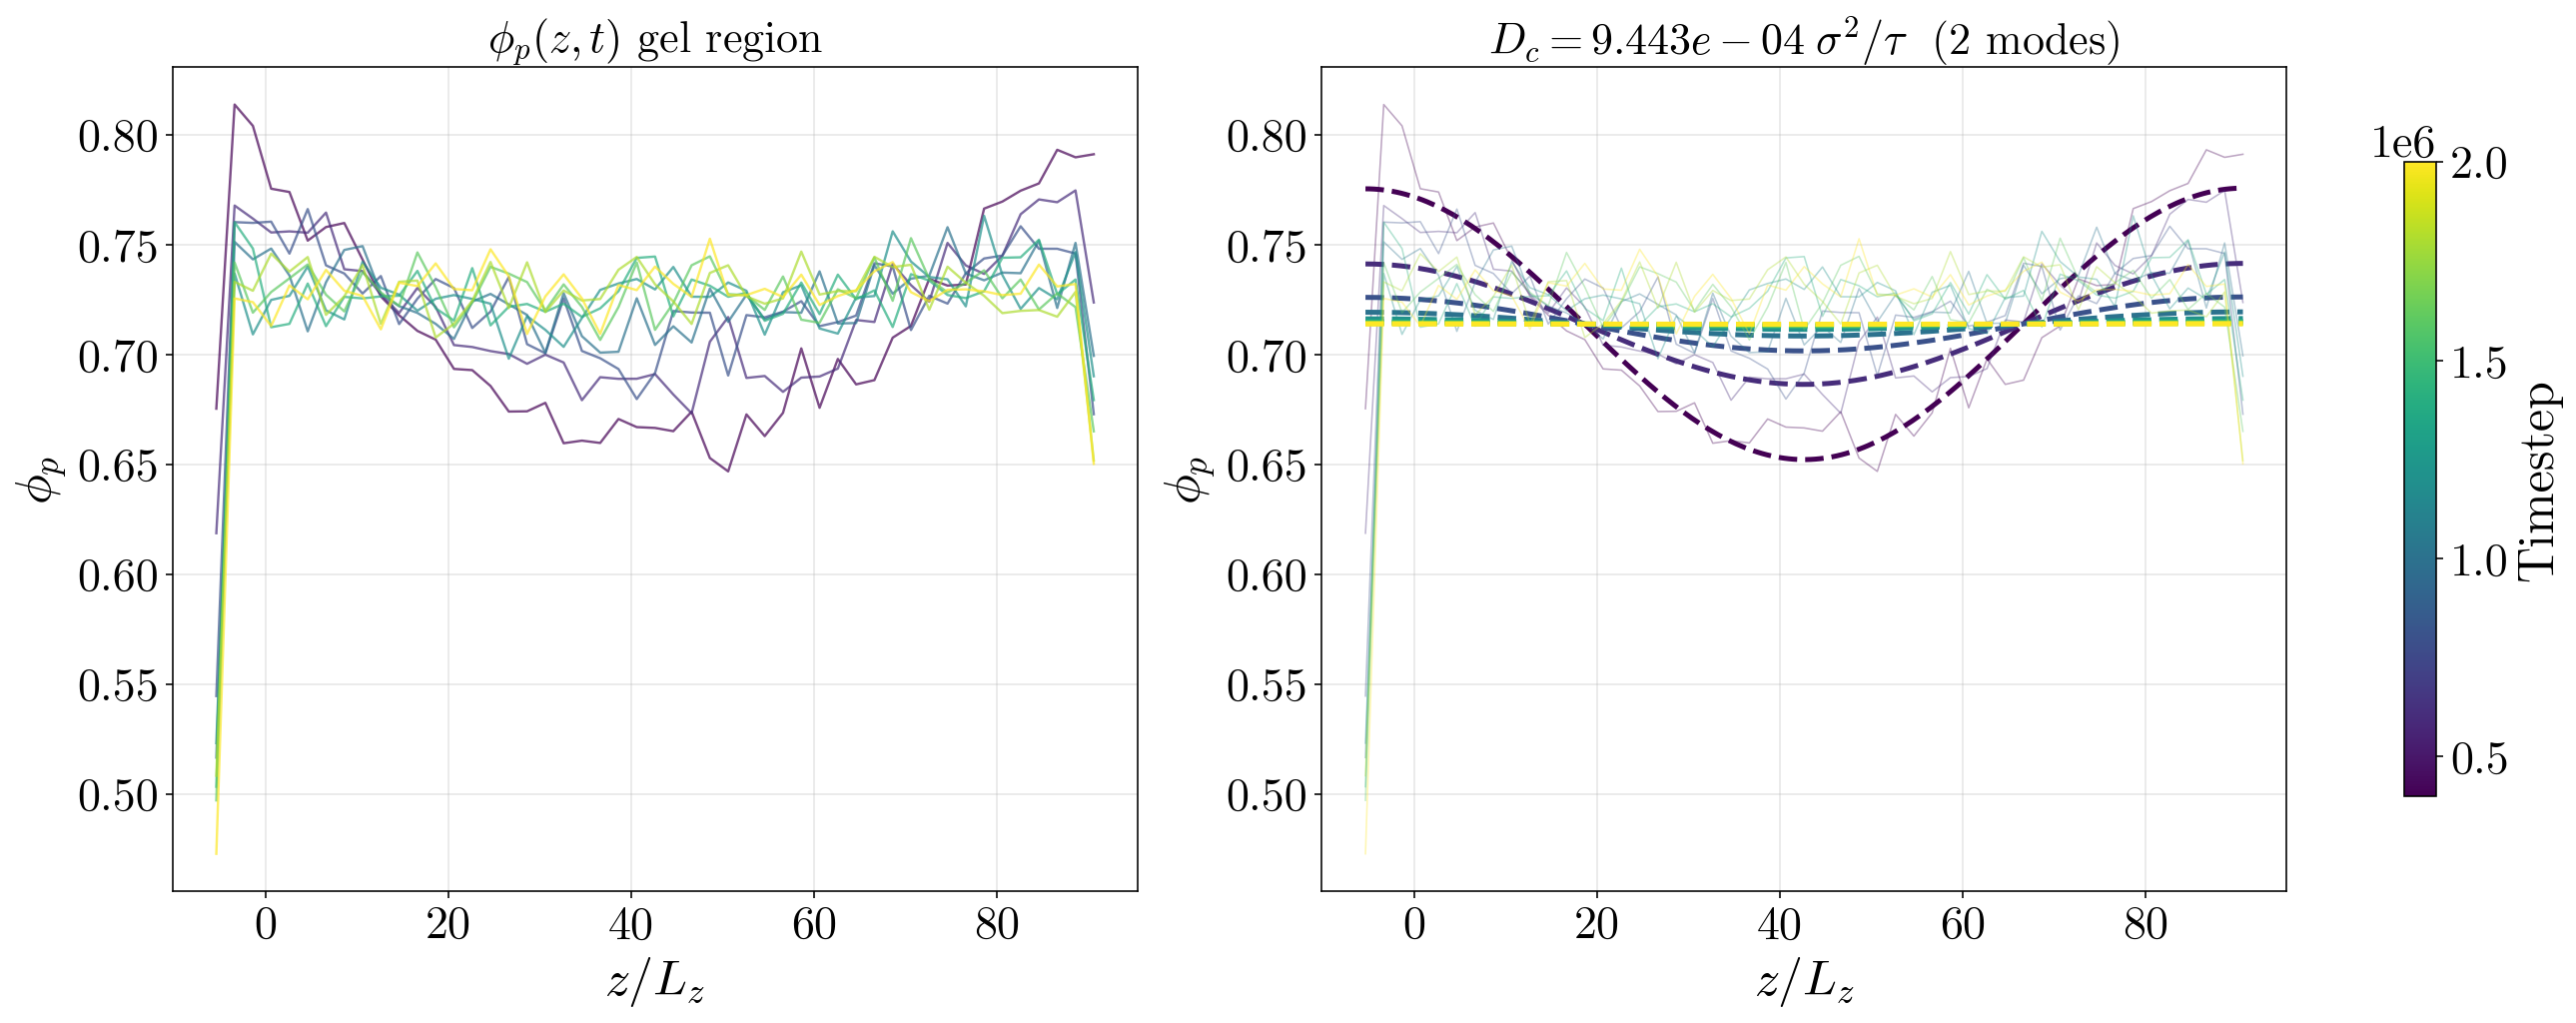

In [27]:
# ── Plot: left = raw φ_p(z,t), right = raw + analytical fit ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
norm = Normalize(vmin=times[0], vmax=times[-1])
cmap = plt.cm.viridis
z_fine = np.linspace(z_L, z_R, 200)

for i in range(len(times)):
    c = cmap(norm(times[i]))
    ax_l.plot(z_gel, phi_gel[i], '-', color=c, lw=1.2, alpha=0.7)
    ax_r.plot(z_gel, phi_gel[i], '-', color=c, lw=0.8, alpha=0.35)
    ax_r.plot(z_fine, phi_model(Dc_fit, z_fine, dt_arr[i]), '--', color=c, lw=2.5)

ax_l.set(xlabel='$z / L_z$', ylabel=r'$\phi_p$', title=r'$\phi_p(z,t)$ gel region')
ax_l.grid(alpha=0.3)
ax_r.set(xlabel='$z / L_z$', ylabel=r'$\phi_p$',
         title=rf'$D_c = {Dc_fit:.3e}\;\sigma^2/\tau$  ({N_modes} modes)')
ax_r.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=[ax_l, ax_r], fraction=0.015, pad=0.04)
cb.set_label('Timestep')

out_dc = Path(output_folder) / f'Dc_fit_{sim_name}.png'
plt.savefig(out_dc, dpi=150, bbox_inches='tight')
print(f'Saved: {out_dc}')
plt.show()

## Step 5: Final-State Profiles

Voronoi volume fractions computed once for the final frame, used for all derived quantities and plots.

In [9]:
from scipy.interpolate import interp1d

idx_final = -1

# Stress components from LAMMPS
sig_p_final = all_sigma_p_zz[idx_final]
sig_s_final = all_sigma_s_zz[idx_final]

# --- Voronoi volume fractions (computed once) ---
print('Computing Voronoi volume fractions for final frame...')
_, box_final, atoms_final = read_lammpstrj_frame(traj_file, matched[idx_final][1])
box_bounds_final = {'x': box_final['x'], 'y': box_final['y'], 'z': box_final['z']}

z_vor, phi_p_vor, phi_s_vor = compute_volume_fractions_1d_voronoi(
    atoms_final, box_bounds_final, binWidth, 'z')

# Voronoi z grid normalised
zlo_f, zhi_f = box_final['z']
Lz_f = zhi_f - zlo_f
z_vor_norm = (z_vor - zlo_f) / Lz_f

# Interpolate Voronoi phi onto the stress bin grid
phi_p_final = interp1d(z_vor, phi_p_vor, bounds_error=False, fill_value=0.0)(z_coords)
phi_s_final = interp1d(z_vor, phi_s_vor, bounds_error=False, fill_value=0.0)(z_coords)


Computing Voronoi volume fractions for final frame...
  Checking for duplicate positions...
  Building Voronoi container (179465 atoms)...
  Container built (15.3s)
  Extracting cell volumes...
  Volumes extracted (2.0s)


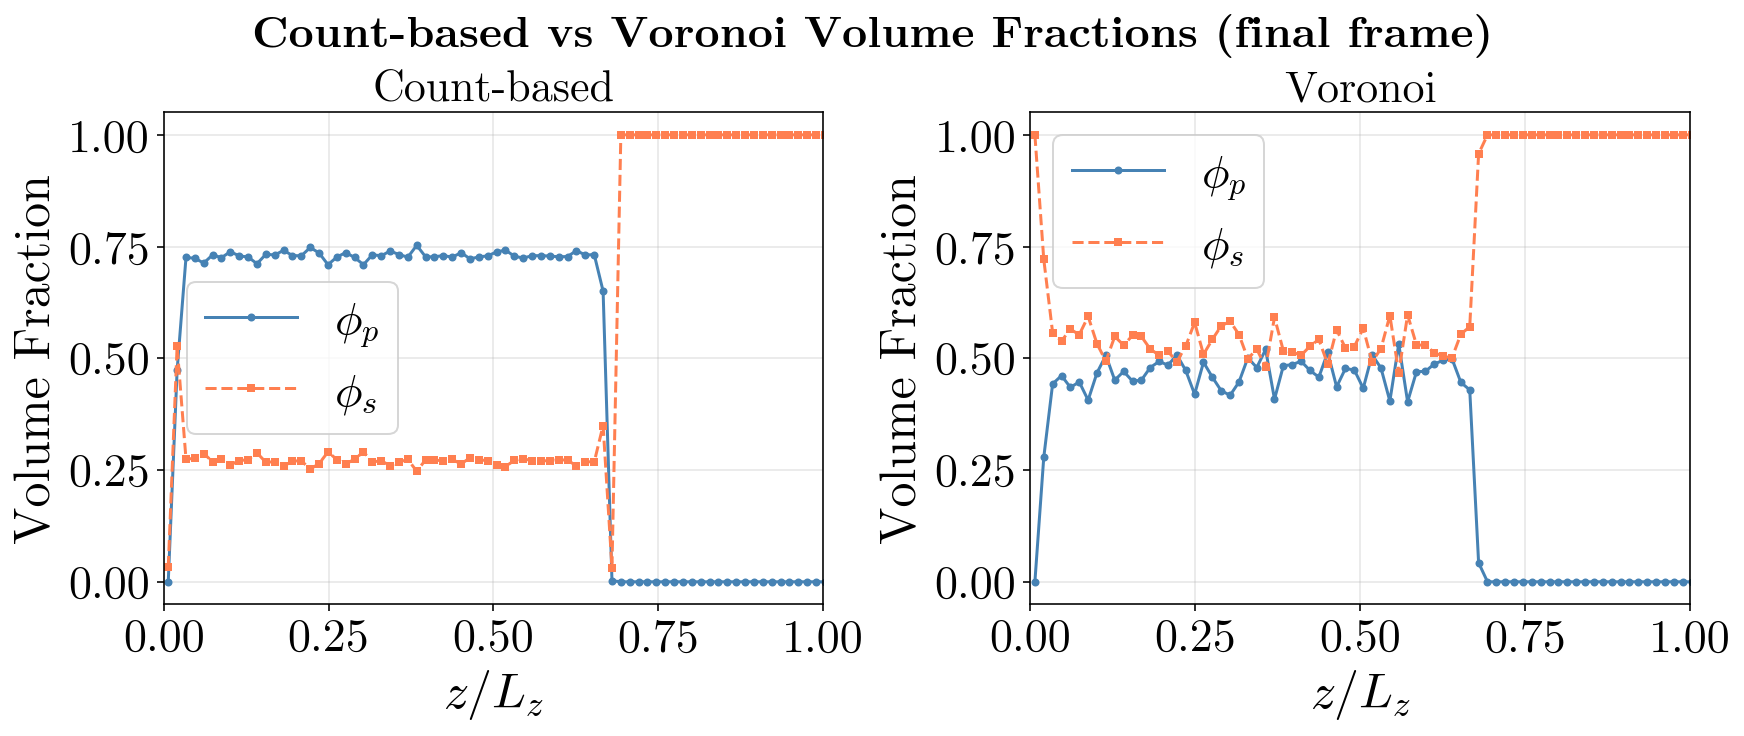

Saved: ../../flow_data_local/flow_plots/final_state_profiles_walled_slab_support_5beads_tall_rho04_1.0_1.0_500000_1.0_1.0_2000000.png


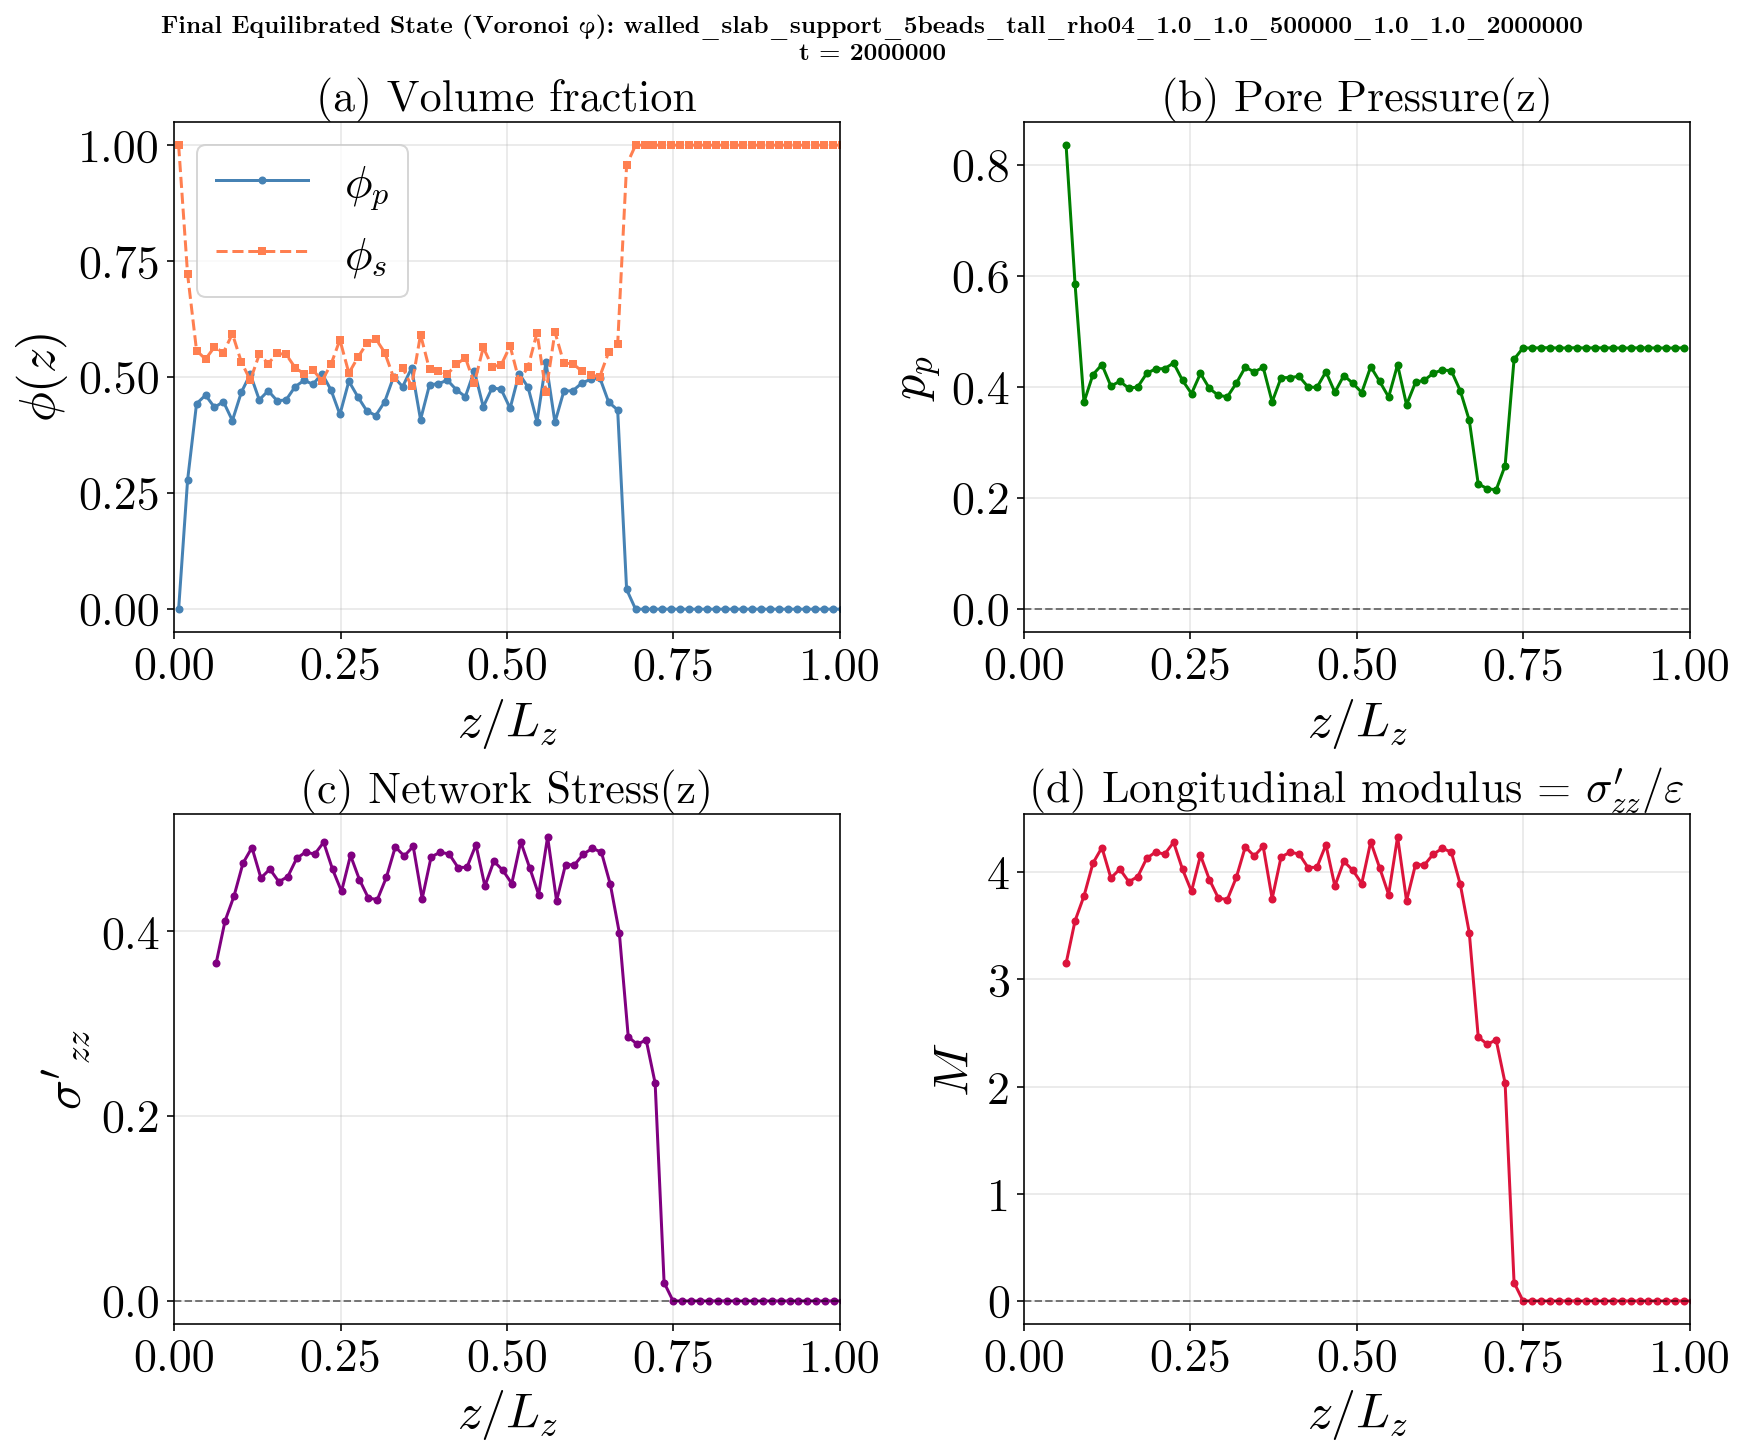

In [10]:
# --- Recompute derived quantities using Voronoi phi ---
phi_s_final_safe = np.where(phi_s_final > 1e-6, phi_s_final, np.nan)
p_p_final       = sig_s_final / phi_s_final_safe
sig_prime_final  = sig_p_final + phi_p_final * np.where(np.isnan(p_p_final), 0.0, p_p_final)

if abs(eps_final) < 1e-12:
    raise ValueError('Final strain ≈ 0 — cannot compute M')

M_final = sig_prime_final / eps_final

# --- Count-based phi (for comparison plot only) ---
z_cnt, phi_p_cnt, phi_s_cnt = compute_volume_fractions_1d(
    atoms_final, box_bounds_final, binWidth, 'z')

# --- Plot 1: Count-based vs Voronoi comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Count-based vs Voronoi Volume Fractions (final frame)', fontweight='bold')

for ax, (phi_p, phi_s, z, label) in zip(axes, [
    (phi_p_cnt, phi_s_cnt, z_cnt, 'Count-based'),
    (phi_p_vor, phi_s_vor, z_vor, 'Voronoi')
]):
    ax.plot((z - zlo_f)/Lz_f, phi_p, 'o-', color='steelblue', ms=3, label=r'$\phi_p$')
    ax.plot((z - zlo_f)/Lz_f, phi_s, 's--', color='coral',    ms=3, label=r'$\phi_s$')
    ax.legend()
    ax.set(xlabel='$z/L_z$', ylabel='Volume Fraction', title=label, xlim=(0,1))
    ax.grid(alpha=0.3)

plt.savefig(Path(output_folder) / f'volfrac_comparison_{sim_name}.png', dpi=150)
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig2.suptitle(
    f'Final Equilibrated State (Voronoi φ): {sim_name}\nt = {all_timesteps[idx_final]}',
    fontsize=12, fontweight='bold')

# (a) φ
ax = axes2[0, 0]
ax.plot(z_vor_norm, phi_p_vor, 'o-', label=r'$\phi_p$', color='steelblue', ms=3)
ax.plot(z_vor_norm, phi_s_vor, 's--', label=r'$\phi_s$', color='coral', ms=3)
ax.legend()
ax.set(xlabel='$z/L_z$', ylabel='$\phi(z)$', title='(a) Volume fraction', xlim=(0,1))
ax.grid(alpha=0.3)

# (b) p_p
ax = axes2[0, 1]
ax.plot(z_norm, p_p_final, 'o-', color='green', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r'$p_p$', title='(b) Pore Pressure(z)', xlim=(0,1))
ax.grid(alpha=0.3)

# (c) σ'
ax = axes2[1, 0]
ax.plot(z_norm, sig_prime_final, 'o-', color='purple', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r"$\sigma'_{zz}$", title=r"(c) Network Stress(z)", xlim=(0,1))
ax.grid(alpha=0.3)

# (d) M
ax = axes2[1, 1]
ax.plot(z_norm, M_final, 'o-', color='crimson', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel='$M$',
       title=r'(d) Longitudinal modulus = $\sigma^{\prime}_{zz}/\varepsilon$', xlim=(0,1))
ax.grid(alpha=0.3)

out2 = Path(output_folder) / f'final_state_profiles_{sim_name}.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
print(f'Saved: {out2}')
plt.show()

## Step 6: Gel-Averaged M with Confidence Interval

**Procedure:**
1. Identify gel bins: where φ_p > threshold (0.05)
2. Extract M values from those bins: $\{M_1, M_2, \dots, M_n\}$
3. Compute sample mean: $\bar{M} = \frac{1}{n}\sum M_i$
4. Compute standard error: $\text{SEM} = s / \sqrt{n}$ where $s = \sqrt{\frac{1}{n-1}\sum(M_i - \bar{M})^2}$
5. Construct 95% CI using t-distribution with $n-1$ degrees of freedom:
   $$\text{CI} = \bar{M} \pm t_{0.975, n-1} \times \text{SEM}$$

**Interpretation:** The CI reflects **spatial heterogeneity** in the gel's stiffness.
Narrow band = uniform; wide band = some bins are stiffer/softer than average.

In [11]:
print('='*70)
print('DERIVATION OF GEL-AVERAGED LONGITUDINAL MODULUS')
print('='*70)

# Step 1: Identify gel bins using Voronoi phi_p (interpolated onto stress grid)
gel_mask = phi_p_final > phi_gel_threshold
n_gel_bins = np.sum(gel_mask)
print(f'\n1. Gel bins identified: {n_gel_bins} / {len(phi_p_final)} (φ_p > {phi_gel_threshold})')

# Step 2: Extract M values
M_gel = M_final[gel_mask]
M_gel = M_gel[~np.isnan(M_gel)]  # remove any NaNs
n_valid = len(M_gel)
print(f'   Valid M values: {n_valid}')
print(f'   M_gel range: [{M_gel.min():.4f}, {M_gel.max():.4f}]')

if n_valid == 0:
    raise ValueError('No valid M values in gel region')

# Step 3: Sample mean
M_mean = np.mean(M_gel)
print(f'\n2. Sample mean: M̄ = {M_mean:.6f}')

# Step 4: Standard error
if n_valid == 1:
    print('\n   WARNING: only 1 data point — CI = point estimate')
    M_ci_lo, M_ci_hi = M_mean, M_mean
else:
    s = np.std(M_gel, ddof=1)  # sample std dev
    sem = stats.sem(M_gel)     # s / sqrt(n)
    print(f'\n3. Sample std dev: s = {s:.6f}')
    print(f'   Standard error: SEM = s/√n = {sem:.6f}')

    # Step 5: t-distribution CI
    df = n_valid - 1
    t_crit = stats.t.ppf((1+ci_level)/2, df)
    margin = t_crit * sem
    M_ci_lo = M_mean - margin
    M_ci_hi = M_mean + margin

    print(f'\n4. t-distribution (df={df}, α={1-ci_level}):')
    print(f'   Critical value: t_{{0.975, {df}}} = {t_crit:.4f}')
    print(f'   Margin of error: {margin:.6f}')

ci_pct = int(ci_level*100)
print(f'\n{"="*70}')
print(f'FINAL RESULT ({ci_pct}% Confidence Interval)')
print(f'{"="*70}')
print(f'  M = {M_mean:.4f}  [{M_ci_lo:.4f}, {M_ci_hi:.4f}]')
print(f'\nStrain: ε_zz = {eps_final:.4f}')
print(f'Gel thickness: L = {L_final:.2f}, ΔL = {dL_final:.2f}')
print('='*70)

DERIVATION OF GEL-AVERAGED LONGITUDINAL MODULUS

1. Gel bins identified: 46 / 75 (φ_p > 0.1)
   Valid M values: 46
   M_gel range: [3.1494, 4.3291]

2. Sample mean: M̄ = 4.002663

3. Sample std dev: s = 0.237915
   Standard error: SEM = s/√n = 0.035079

4. t-distribution (df=45, α=0.050000000000000044):
   Critical value: t_{0.975, 45} = 2.0141
   Margin of error: 0.070652

FINAL RESULT (95% Confidence Interval)
  M = 4.0027  [3.9320, 4.0733]

Strain: ε_zz = 0.1160
Gel thickness: L = 116.21, ΔL = 13.48


## Optional: Save Data

In [ ]:
out_data = Path(output_folder) / f'longitudinal_modulus_final_{sim_name}.npz'
np.savez(out_data,
         z_coords=z_coords, z_norm=z_norm,
         z_centers=z_centers, z_centers_norm=z_centers_norm,
         z_vor=z_vor, z_vor_norm=z_vor_norm,
         final_timestep=all_timesteps[idx_final],
         L=L_final, dL=dL_final, eps=eps_final,
         phi_p=phi_p_final, phi_s=phi_s_final,
         phi_p_vor=phi_p_vor, phi_s_vor=phi_s_vor,
         p_p=p_p_final, sigma_p_zz=sig_p_final, sigma_s_zz=sig_s_final,
         sigma_prime_zz=sig_prime_final, M=M_final,
         M_mean=M_mean, M_ci_lo=M_ci_lo, M_ci_hi=M_ci_hi,
         ci_level=ci_level, n_gel_bins=n_gel_bins,
         sim_name=sim_name)
print(f'Saved: {out_data}')